In [1]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [2]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [3]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [4]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [5]:

!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

In [1]:
import numpy as np
import pandas as pd
import os, glob, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gtda.time_series import SingleTakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, NumberOfPoints, BettiCurve
from gtda.diagrams import Scaler as DiagramScaler
from gtda.curves import StandardFeatures

In [2]:

# ── CELL 4: Config ────────────────────────────────────────────────
DATA_DIR = "./GAMEEMO"

CHANNELS = ["AF3","F7","F3","FC5","T7","P7","O1","O2","P8","T8","FC6","F4","F8","AF4"]

EMOTIONS = {"G1": "Boring", "G2": "Calm", "G3": "Horror", "G4": "Funny"}
EMOTION_LABELS = list(EMOTIONS.values())
N_SUBJECTS = 28


TIME_DELAY = 2   # starting guess for search
DIMENSION  = 3   # starting guess for search

# 10-second windows, 50% overlap, at 128 Hz (EMOTIV EPOC sampling rate)
FS            = 128
SW_SIZE       = FS * 10      # 1280 samples ≈ 10s
SW_STRIDE     = SW_SIZE // 2 # 640 samples  ≈ 5s hop (50% overlap)

HOMOLOGY_DIMS = (0, 1)

RANDOM_STATE = 42


In [3]:
#CELL 5: Load one subject's data ───────────────────────────────
def load_subject(subject_id):
    all_X, all_y = [], []

    csv_dir = os.path.join(
        DATA_DIR,
        f"(S{subject_id:02d})",
        "Preprocessed EEG Data",
        ".csv format"
    )

    for game_tag in EMOTIONS:
        label = list(EMOTIONS.keys()).index(game_tag)
        fname = f"S{subject_id:02d}{game_tag}AllChannels.csv"
        fpath = os.path.join(csv_dir, fname)

        if not os.path.exists(fpath):
            print(f"  [warn] not found: {fname}")
            continue

        df   = pd.read_csv(fpath)
        cols = [c for c in df.columns if c in CHANNELS]
        if not cols:
            cols = df.select_dtypes(include=np.number).columns[:14].tolist()

        data = df[cols].values.astype(np.float64) #here data is storing values like just of our dataset total n timestamps in rows and 14 colums, that way only in  numpy ,represmtation different yet all same

        all_X.append(data)                                    # keep as separate block
        all_y.append(np.full(len(data), label, dtype=int))

    if not all_X:
        raise FileNotFoundError(f"No CSVs found for S{subject_id:02d}")

    # Return list of (X_block, y_block) per emotion — NOT concatenated.
    # Concatenating here and splitting 80/20 afterwards would put the
    # entire test set inside the last emotion block (G4/Funny) only.
    return all_X, all_y




In [4]:

# i.e. the most significant topological feature in each window, for H0 and H1.
def persistence_main(X_pd):
    n_windows = X_pd.shape[0]
    rows = []
    for w in range(n_windows):
        row = []
        for dim in HOMOLOGY_DIMS:
            pts    = X_pd[w][X_pd[w, :, 2] == dim]
            finite = pts[np.isfinite(pts[:, 1])]
            if len(finite) == 0:
                row.append(0.0)
            else:
                lifetimes = finite[:, 1] - finite[:, 0]   # death - birth
                row.append(lifetimes.max())
        rows.append(row)
    return np.array(rows)  # (n_windows, len(HOMOLOGY_DIMS))


In [5]:

# ── TDA features for one channel — REDUCED to main persistence + entropy ──
def tda_on_signal(signal, labels):
    """
    Run TDA pipeline on a 1-D signal. Each call independently searches
    for the optimal time_delay/dimension for THIS signal only.

    signal : (T,)
    labels : (T,)

    Returns
    -------
    X_feat : (n_windows, 4)   -> [main_H0, main_H1, entropy_H0, entropy_H1]
    y_win  : (n_windows,)
    """
    # Step 1 — SingleTakensEmbedding, per-channel optimal params via search.
    STE = SingleTakensEmbedding(
        parameters_type="search",
        time_delay=TIME_DELAY,
        dimension=DIMENSION,
        n_jobs=-1,
    )
    X_emb, y_emb = STE.fit_transform_resample(signal, labels)

    # Step 2 — SlidingWindow over embedded point cloud (10s windows, 50% overlap)
    SW = SlidingWindow(size=SW_SIZE, stride=SW_STRIDE)
    X_win, y_win = SW.fit_transform_resample(X_emb, y_emb)

    # Step 3 — VietorisRipsPersistence
    VR   = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=-1)
    X_pd = VR.fit_transform(X_win)
    X_pd = DiagramScaler().fit_transform(X_pd)

    # Step 4 — ONLY main persistence (max lifetime) + persistence entropy
    feat_main = persistence_main(X_pd)                                                    # (n_win, 2)
    feat_pe   = PersistenceEntropy(normalize=True, nan_fill_value=0.0).fit_transform(X_pd) # (n_win, 2)

    X_feat = np.hstack([feat_main, feat_pe])   # (n_win, 4)
    return X_feat, y_win


In [6]:

# ── Extract FULL features for one subject (no 80/20 split — LOSO needs the whole subject) ──
def extract_subject_features_full(subject_id):
    """
    Load subject as 4 emotion blocks (full length, no split). For each
    emotion block, run per-channel TDA (4 feats/channel), hstack channels,
    then vstack all 4 emotion blocks. Returns this subject's FULL feature
    matrix + labels — used as a whole in whichever LOSO fold needs it.
    """
    blocks_X, blocks_y = load_subject(subject_id)

    block_feats, block_labels = [], []

    for X_block, y_block in zip(blocks_X, blocks_y):
        n_channels = X_block.shape[1]
        ch_feats = []
        min_win = None
        y_win_ref = None

        for ch_idx in range(n_channels):
            f, yw = tda_on_signal(X_block[:, ch_idx], y_block)
            ch_feats.append(f)
            if min_win is None:
                min_win, y_win_ref = f.shape[0], yw
            else:
                min_win = min(min_win, f.shape[0])

        block_X = np.hstack([f[:min_win] for f in ch_feats])   # (n_win, 14*4=56)
        block_y = y_win_ref[:min_win]

        block_feats.append(block_X)
        block_labels.append(block_y)

    X_full = np.vstack(block_feats)
    y_full = np.concatenate(block_labels)

    X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"  S{subject_id:02d} -> features={X_full.shape}")
    return X_full, y_full


In [7]:

# ── CELL 9: Confusion matrix plot ─────────────────────────────────
def plot_cm(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTION_LABELS,
                yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [8]:

# ── Extract & CACHE features for all subjects ONCE ────────────────
# This is the only expensive TDA pass. Every LOSO fold below just
print("Extracting TDA features for all subjects (cached once for LOSO)...")

subject_features = {}   # sid -> (X, y)

for sid in range(1, 5):
    print(f"\n{'='*50}\nSubject S{sid:02d}\n{'='*50}")
    try:
        X_sub, y_sub = extract_subject_features_full(sid)
        subject_features[sid] = (X_sub, y_sub)
    except FileNotFoundError as e:
        print(f"  [skip] {e}")
    except Exception as e:
        print(f"  [error] {e}")

print(f"\nCached features for {len(subject_features)} subjects.")


Extracting TDA features for all subjects (cached once for LOSO)...

Subject S01
  S01 -> features=(232, 56)

Subject S02
  S02 -> features=(232, 56)

Subject S03
  S03 -> features=(232, 56)

Subject S04
  S04 -> features=(232, 56)

Cached features for 4 subjects.


In [12]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_selection import VarianceThreshold

class TDA_MLP(nn.Module):
    def __init__(self, in_dim, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def train_fold_mlp(X_tr, y_tr, X_te, y_te, fold_id):
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_te_sc  = scaler.transform(X_te)

    selector = VarianceThreshold(threshold=0.01)
    X_tr_sc  = selector.fit_transform(X_tr_sc)
    X_te_sc  = selector.transform(X_te_sc)

    X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr,    dtype=torch.long)
    X_te_t = torch.tensor(X_te_sc, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=256, shuffle=True)

    device    = "cuda" if torch.cuda.is_available() else "cpu"
    model     = TDA_MLP(in_dim=X_tr_sc.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    EPOCHS       = 100
    PATIENCE     = 10
    best_val_acc = 0.0
    best_weights = None
    patience_ctr = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()
        val_acc = accuracy_score(y_te, val_pred)
        scheduler.step(1 - val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break
        model.train()

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_te_t.to(device)).argmax(1).cpu().numpy()

    acc = accuracy_score(y_te, y_pred)
    print(f"  Fold (held-out {fold_id}) — best_val_acc={best_val_acc:.4f}, test_acc={acc:.4f}")
    return acc, y_te, y_pred


In [13]:

# ── LOSO: Leave-One-Subject-Out ────────────────────────────────────
print("LOSO evaluation...\n")

sids = sorted(subject_features.keys())
loso_results = []
all_y_te_loso, all_y_pred_loso = [], []

for held_out in sids:
    train_sids = [s for s in sids if s != held_out]

    X_tr = np.vstack([subject_features[s][0] for s in train_sids])
    y_tr = np.concatenate([subject_features[s][1] for s in train_sids])
    X_te, y_te = subject_features[held_out]

    acc, y_te_f, y_pred_f = train_fold_mlp(X_tr, y_tr, X_te, y_te, f"S{held_out:02d}")
    loso_results.append({"held_out_subject": f"S{held_out:02d}", "accuracy": acc})
    all_y_te_loso.extend(y_te_f)
    all_y_pred_loso.extend(y_pred_f)


LOSO evaluation...

  Fold (held-out S01) — best_val_acc=0.5000, test_acc=0.5000
  Fold (held-out S02) — best_val_acc=0.2371, test_acc=0.2371
  Fold (held-out S03) — best_val_acc=0.2500, test_acc=0.2500
  Fold (held-out S04) — best_val_acc=0.2802, test_acc=0.2802



LOSO mean accuracy : 0.3168 +/- 0.1235
held_out_subject  accuracy
             S01  0.500000
             S02  0.237069
             S03  0.250000
             S04  0.280172

Overall classification report (pooled across all held-out folds):
              precision    recall  f1-score   support

      Boring       0.37      0.23      0.28       232
        Calm       0.23      0.51      0.32       232
      Horror       0.55      0.27      0.36       232
       Funny       0.39      0.25      0.31       232

    accuracy                           0.32       928
   macro avg       0.38      0.32      0.32       928
weighted avg       0.38      0.32      0.32       928



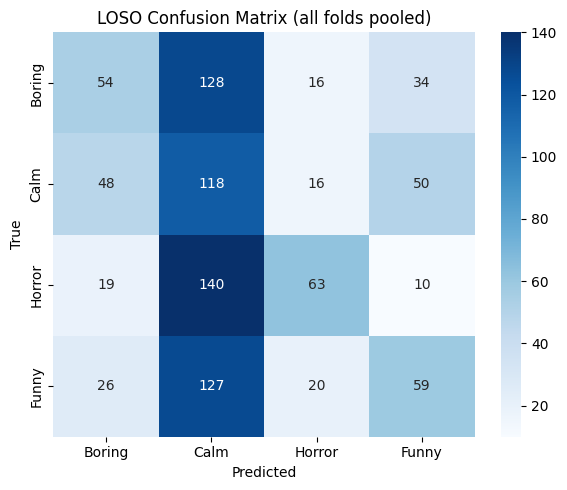

In [14]:

# ── LOSO Summary ────────────────────────────────────────────────────
df_loso  = pd.DataFrame(loso_results)
mean_acc = df_loso["accuracy"].mean()
std_acc  = df_loso["accuracy"].std()

print(f"\n{'='*50}")
print(f"LOSO mean accuracy : {mean_acc:.4f} +/- {std_acc:.4f}")
print(f"{'='*50}")
print(df_loso.to_string(index=False))

print(f"\nOverall classification report (pooled across all held-out folds):")
print(classification_report(all_y_te_loso, all_y_pred_loso, target_names=EMOTION_LABELS))

plot_cm(all_y_te_loso, all_y_pred_loso, "LOSO Confusion Matrix (all folds pooled)")
